<a href="https://colab.research.google.com/github/sharaddsingh/Supply_Chain_DA/blob/main/SupplyChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("../DataCoSupplyChainDataset.csv",encoding='latin1')

In [25]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [26]:
drop_cols = [
    "Product Description",
    "Order Zipcode"
]

df = df.drop(columns=drop_cols)

In [27]:
df.shape

(180519, 51)

In [28]:
print(df.duplicated().sum())

df = df.drop_duplicates()

0


In [29]:
df["Customer Lname"] = df["Customer Lname"].fillna("Unknown")

df["Customer Zipcode"] = df["Customer Zipcode"].fillna(
    df["Customer Zipcode"].median()
)

In [30]:
date_cols = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [31]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
      .str.replace("(", "")
      .str.replace(")", "")
)

In [32]:
df["Delivery_Delay"] = (
    df["Days_for_shipping_real"]
    -
    df["Days_for_shipment_scheduled"]
)

In [33]:
df["Profit_Margin"] = (
    df["Benefit_per_order"] /
    df["Sales_per_customer"]
) * 100

In [34]:
df["Order_Month"] = df["order_date_DateOrders"].dt.month_name()

In [35]:
df["Order_Year"] = df["order_date_DateOrders"].dt.year

In [36]:
df["Quarter"] = df["order_date_DateOrders"].dt.quarter

In [37]:
df["Weekday"] = df["order_date_DateOrders"].dt.day_name()

In [38]:


df.isnull().sum()

,0
Type,0
Days_for_shipping_real,0
Days_for_shipment_scheduled,0
Benefit_per_order,0
Sales_per_customer,0
Delivery_Status,0
Late_delivery_risk,0
Category_Id,0
Category_Name,0
Customer_City,0


(array([7.5320e+03, 1.9538e+04, 2.1238e+04, 3.4651e+04, 3.4137e+04,
        6.2770e+03, 9.4140e+03, 2.2281e+04, 8.1900e+02, 1.9987e+04,
        0.0000e+00, 1.1220e+03, 2.5510e+03, 4.8400e+02, 2.1000e+01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 4.4200e+02, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5000e+01]),
 array([   9.98999977,   49.78999958,   89.58999938,  129.38999918,
         169.18999899,  208.98999879,  248.7899986 ,  288.5899984 ,
         328.38999821,  368.18999801,  407.98999782,  447.78999762,
         487.58999743,  527.38999723,  567.18999704,  606.98999684,
         646.78999664,  686.58999645,  726.389

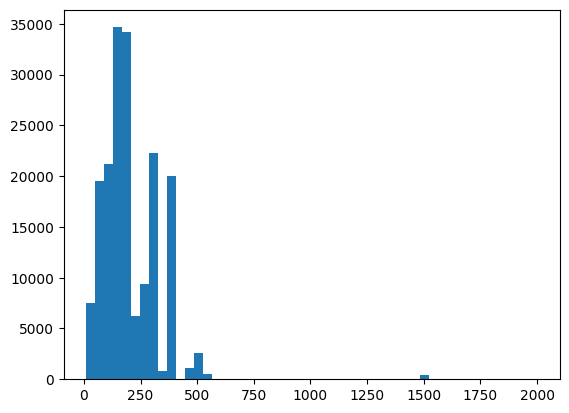

In [39]:
plt.hist(df["Sales"], bins=50)

(array([1.00000e+00, 2.00000e+00, 1.00000e+00, 8.00000e+00, 1.00000e+01,
        1.40000e+01, 4.75000e+02, 9.38300e+03, 1.70423e+05, 2.02000e+02]),
 array([-4274.97998   , -3756.30198322, -3237.62398644, -2718.94598966,
        -2200.26799288, -1681.5899961 , -1162.91199932,  -644.23400254,
         -125.55600576,   393.12199102,   911.7999878 ]),
 <BarContainer object of 10 artists>)

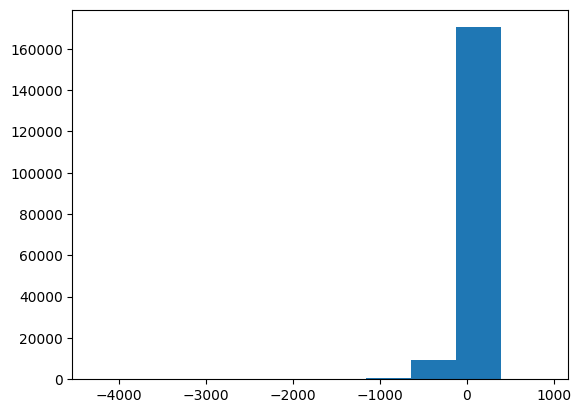

In [40]:
plt.hist(df["Benefit_per_order"])

In [41]:
df["Shipping_Mode"].value_counts()

,count
Shipping_Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


In [42]:
df["Delivery_Status"].value_counts()

,count
Delivery_Status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


In [43]:
df.groupby("Category_Name")["Sales"].sum().sort_values()

,Sales
Category_Name,
CDs,3.059590e+03
Toys,6.104660e+03
Golf Bags & Carts,1.036939e+04
Baby,1.222956e+04
Books,1.258740e+04
As Seen on TV!,2.059794e+04
Soccer,2.647705e+04
Basketball,2.709933e+04
Video Games,3.331050e+04


In [44]:
df.groupby("Order_Country")["Sales"].sum()

,Sales
Order_Country,
Afganistán,3.856886e+04
Albania,8.299130e+03
Alemania,2.074172e+06
Angola,5.766602e+04
Arabia Saudí,1.631497e+05
...,...
Vietnam,1.663643e+05
Yemen,1.310628e+04
Yibuti,6.569370e+03


In [45]:
df.groupby("Product_Name")["Sales"].sum()

,Sales
Product_Name,
Adult dog supplies,41524.800753
Baby sweater,12229.560379
Bag Boy Beverage Holder,21116.549776
Bag Boy M330 Push Cart,16637.919929
Bowflex SelectTech 1090 Dumbbells,5999.899902
...,...
adidas Kids' F5 Messi FG Soccer Cleat,27327.190540
adidas Men's F10 Messi TRX FG Soccer Cleat,56330.611645
adidas Men's Germany Black Crest Away Tee,21475.000000


In [46]:
df["Late_delivery_risk"].value_counts(normalize=True)

,proportion
Late_delivery_risk,
1,0.548291
0,0.451709


In [47]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,Days_for_shipping_real,Days_for_shipment_scheduled,Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Customer_Id,Customer_Zipcode,Department_Id,Latitude,...,Order_Item_Total,Order_Profit_Per_Order,Product_Card_Id,Product_Category_Id,Product_Price,Product_Status,Delivery_Delay,Profit_Margin,Order_Year,Quarter
Days_for_shipping_real,1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,0.003432,0.000113,-0.001631,-0.004073,...,0.001757,-0.005101,-0.000859,-0.000348,0.002185,NaN,0.613475,-0.004639,0.000842,-0.007416
Days_for_shipment_scheduled,0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,0.000899,-0.003019,-0.000262,-0.005300,...,0.006445,-0.000185,-0.000431,-0.000367,0.006912,NaN,-0.360037,-0.001829,0.000656,-0.007105
Benefit_per_order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.009354,0.002233,0.031442,0.000338,...,0.133484,1.000000,0.033161,0.031889,0.103459,NaN,-0.005385,0.823695,0.010703,0.009730
Sales_per_customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.060181,-0.001304,0.232367,-0.000223,...,1.000000,0.133484,0.236367,0.225201,0.781781,NaN,-0.004028,-0.001432,0.059581,0.062931
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001484,0.003151,0.001077,0.000679,...,-0.003791,-0.003727,0.001490,0.001752,-0.002175,NaN,0.777644,-0.002309,-0.002181,0.001076
Category_Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.274633,0.002881,0.888835,0.002195,...,0.225201,0.031889,0.991092,1.000000,0.461059,NaN,-0.000040,-0.001623,0.179645,0.072164
Customer_Id,0.003432,0.000899,0.009354,0.060181,0.001484,0.274633,1.000000,0.002007,0.136897,0.002335,...,0.060181,0.009354,0.228039,0.274633,0.111118,NaN,0.002909,-0.000342,0.189759,0.060697
Customer_Zipcode,0.000113,-0.003019,0.002233,-0.001304,0.003151,0.002881,0.002007,1.000000,0.002868,0.584544,...,-0.001304,0.002233,0.003159,0.002881,0.002187,NaN,0.002906,0.003364,-0.001221,-0.000882
Department_Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,0.136897,0.002868,1.000000,0.002460,...,0.232367,0.031442,0.906117,0.888835,0.446743,NaN,-0.001534,-0.003054,0.095492,0.045302
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002335,0.584544,0.002460,1.000000,...,-0.000223,0.000338,0.002031,0.002195,0.000471,NaN,0.000450,-0.000075,-0.001759,-0.002798
